# DSCI 633 Project
### Predicting Readmittance within 30 Days for Hospitalized Diabetes Patients  
*Michael Eaton, Rochester Institute of Technology — Fall 2025*

In [9]:
from shared_util.dataio import load_csv
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
PLOT_ID = 1 # set to the id you want to see plotted if there are more than 1 run of a model

In [11]:
df = load_csv('metrics')

df = df.reset_index()

df = df.sort_values(by='roc_auc', ascending=False)

In [12]:
df[(df['data'] == 'test') | (df['data'] == 'validate')].head(20)

,id,model,data,threshold_notes,pipeline_notes,hyperparam_notes,notes,roc_auc,accuracy,precision,recall,f1,TN,TP,FP,FN
3,0,rf,test,f2_weighted,under_sample,tuned_best_roc_auc,NaN,0.677547,0.433314,0.124256,0.798436,0.215046,4211.0,919.0,6477.0,232.0
8,1,sgd,test,f2_weighted,under_sample,tuned best ROC,with log transform,0.669741,0.403497,0.120457,0.814944,0.209890,3839.0,938.0,6849.0,213.0
11,1,svc,test,f2_weighted,under_sample,"tuned best roc, uses HalvingRandomSearchCV",with log transform,0.669585,0.348847,0.115682,0.857515,0.203862,3143.0,987.0,7545.0,164.0
7,1,sgd,validate,base,under_sample,tuned best roc,with log transform,0.641424,0.662409,0.154999,0.522351,0.239060,7251.0,631.0,3440.0,577.0
4,0,rf+int,validate,base,under_sample,tuned_best_roc_auc,NaN,0.640761,0.653164,0.153572,0.535596,0.238701,7125.0,647.0,3566.0,561.0
2,0,rf,validate,base,under_sample,tuned_best_roc_auc,NaN,0.639747,0.642239,0.151861,0.550497,0.238053,6977.0,665.0,3714.0,543.0
10,1,svc,validate,base,under_sample,tuned best roc,with log transform,0.636384,0.697370,0.162101,0.475166,0.241735,7724.0,574.0,2967.0,634.0
15,0,xgboost,test,f2_weighted,under_sample,tuned best F2,first pass,0.633935,0.372329,0.111867,0.786273,0.195866,3503.0,905.0,7185.0,246.0
14,0,xgboost,validate,base,under_sample,tuned best roc_auc,first pass,0.610539,0.587276,0.136176,0.573675,0.220105,6295.0,693.0,4396.0,515.0


In [13]:
import pandas as pd

def filter_duplicates_by_id(df, keep_id):
    
    key_cols = ['model', 'data', 'threshold_notes', 'pipeline_notes']
    
    
    duplicated_mask = df.duplicated(subset=key_cols, keep=False)

    duplicates = df[duplicated_mask]
    uniques = df[~duplicated_mask]
    
    kept_duplicates = duplicates[duplicates['id'] == keep_id]
    
    result = pd.concat([uniques, kept_duplicates], ignore_index=True)
    
    return result.sort_values(by='roc_auc', ascending=False).reset_index(drop=True)





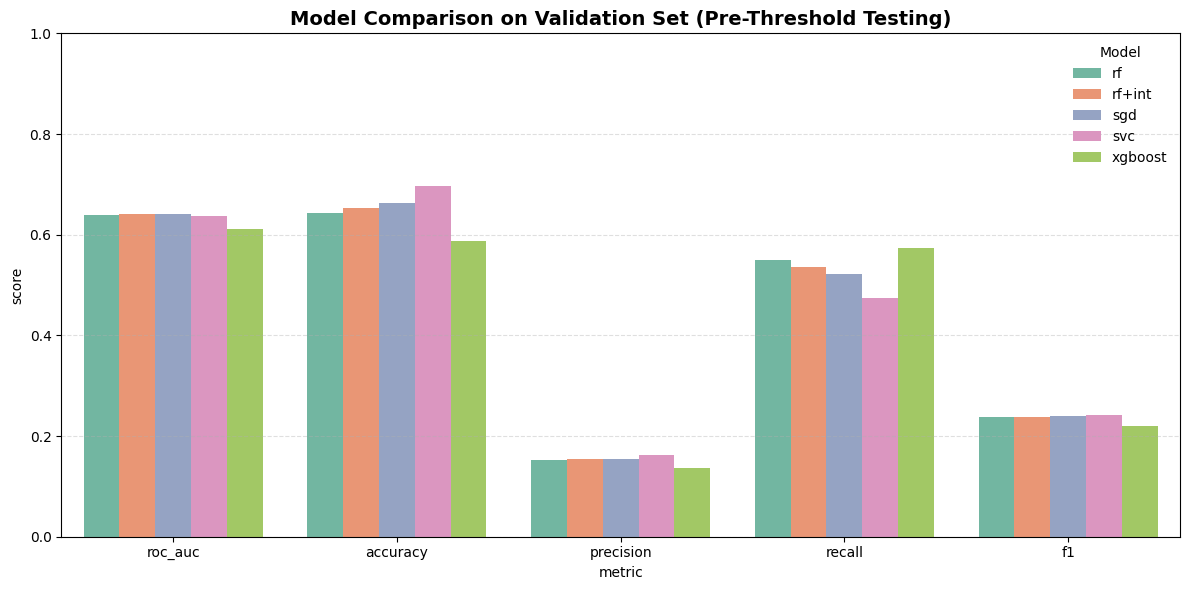

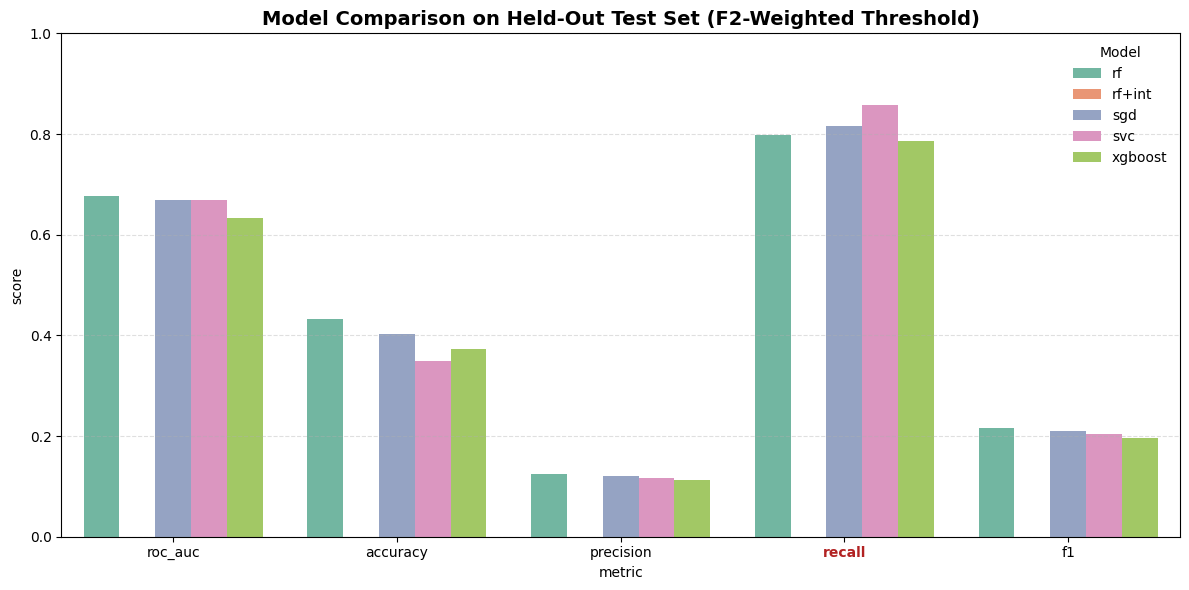

In [14]:
# numeric metrics
metrics = ["roc_auc", "accuracy", "precision", "recall", "f1"]

# keep only the chosen id for duplicated test

df_filtered = filter_duplicates_by_id(df, keep_id=PLOT_ID)


# ensure model column sorted nicely for consistent colors
df_filtered["model"] = df_filtered["model"].astype("category")
model_order = sorted(df_filtered["model"].unique())
palette = sns.color_palette("Set2", len(model_order))



# melt for plotting
melted = df_filtered.melt(
    id_vars=["model", "data"],
    value_vars=metrics,
    var_name="metric",
    value_name="score"
)

# helper to make consistent chart layout
def plot_metrics(subset, title, emphasize=None):
    plt.figure(figsize=(12,6))
    sns.barplot(
        data=subset,
        x="metric", y="score",
        hue="model",
        palette=palette,
        errorbar=None
    )
    plt.ylim(0, 1)
    plt.title(title, fontsize=14, weight="bold")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    if emphasize:
        plt.axhline(0, color="none") 
        # slightly bold recall bars
        bars = plt.gca().patches
        for b in bars:
            if b.get_x() < 0:  #type: ignore
                continue
        # recolor recall tick label
        xticks = plt.gca().get_xticklabels()
        for t in xticks:
            if t.get_text().lower() == emphasize.lower():
                t.set_weight("bold") #type: ignore
                t.set_color("#b22222")
    plt.legend(title="Model", frameon=False)
    plt.tight_layout()
    plt.show()


# --- Plot 1: Validation (pre-threshold) ---
validate_df = melted[melted["data"] == "validate"]
plot_metrics(validate_df,
             "Model Comparison on Validation Set (Pre-Threshold Testing)")

# --- Plot 2: Test (F2-weighted, recall-focused) ---
test_df = melted[melted["data"] == "test"]
plot_metrics(test_df,
             "Model Comparison on Held-Out Test Set (F2-Weighted Threshold)",
             emphasize="recall")

In [15]:
import numpy as np
# test by roc
df_collapse = filter_duplicates_by_id(df, PLOT_ID)

df_collapse = df_collapse.sort_values(by='roc_auc', ascending=False)

df_collapse = df_collapse = df_collapse[df_collapse['data'] == 'test']

df_collapse['roc_auc'] = np.round(df_collapse['roc_auc'], 3)

print('Models by ROC_AUC')
display(df_collapse.head(5)[['model', 'roc_auc']])


Models by ROC_AUC


,model,roc_auc
0,rf,0.678
1,sgd,0.670
2,svc,0.670
9,xgboost,0.634


In [16]:
df_collapse = df_collapse.sort_values(by='recall', ascending=False)
df_collapse = df_collapse = df_collapse[df_collapse['data'] == 'test']
df_collapse['recall'] = np.round(df_collapse['recall'], 3)

print('Models by Recall')
display(df_collapse.head(5)[['model', 'recall']])

Models by Recall


,model,recall
2,svc,0.858
1,sgd,0.815
0,rf,0.798
9,xgboost,0.786


<hr>